# 22 — Le test de forme, et ce qu'il ne peut pas séparer

Le [notebook 21](21_angles_morts.ipynb) s'est terminé sur une piste, et une seule :

> Tester la **forme** de l'examen, pas seulement son existence. Sous cascade, l'examen d'un rang
> dépend des **clics au-dessus**, ce qui laisse une signature qu'un test conditionnel pourrait
> détecter. Ce serait le troisième contrôle de la série, après l'échangeabilité et
> l'identifiabilité.

Ce notebook le construit. Il fonctionne — puis il rencontre une limite qui n'est pas la sienne.

**Ce que ce notebook établit :**

* le test **fonctionne** : il ne rejette jamais sous un modèle de position ($|z| < 1$ à toutes
  les sévérités) et rejette massivement sous cascade ($z = -97$ à $-307$) ;
* mais un **budget de clics** — un lecteur qui cesse de cliquer une fois servi, tout en
  continuant de parcourir le fil — produit **la même signature** : $z = -144$ sous modèle de
  position pur. Les deux ne sont **pas séparables** dans des données de clic seules ;
* appliqué à **Baidu-ULTR**, le test ne trouve **aucune signature de cascade** : $z = +5{,}6$ au
  seuil le plus permissif, $+0{,}5$ au plus strict — le signe est celui du confondant, pas celui
  de la cascade ;
* et une **erreur de protocole**, découverte en la commettant : restreindre le journal aux
  sessions à plusieurs clics fabrique la signature recherchée. Sur un modèle de position pur, la
  restriction fait passer $z$ de $+0{,}7$ à $\mathbf{-45{,}7}$. C'est un *collider*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.exposure import load_digest
from ide.logs import (
    Impressions,
    simulate_cascade,
    simulate_feeds,
    upstream_dependence_from_counts,
    upstream_dependence_test,
)
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

CATALOGUE, FEEDS, SLOTS = 200, 60_000, 12
print(f"{FEEDS} fils de {SLOTS} positions, catalogue de {CATALOGUE} contenus")

60000 fils de 12 positions, catalogue de 200 contenus


## 1. La construction

Les deux formes d'examen ne se distinguent pas par leur allure — une décroissance géométrique et
une décroissance polynomiale s'ajustent aussi bien l'une que l'autre sur les premiers rangs. Elles
se distinguent par une **indépendance conditionnelle** :

* sous un modèle de **position**, l'examen du rang $R$ ne dépend que de $R$ : à contenu et rang
  fixés, le clic est indépendant de ce qui s'est passé au-dessus ;
* sous un modèle **à cascade**, un clic au-dessus **supprime** l'examen en dessous.

Pour chaque cellule $s = (\text{contenu}, \text{rang})$, les $n_s$ impressions se répartissent en
$n_{1s}$ précédées d'un clic dans le même fil et $n_{0s}$ qui ne le sont pas, pour $k_s$ clics au
total. Sous l'hypothèse d'indépendance, les $k_s$ clics se répartissent comme un tirage sans
remise, de moments connus exactement :

$$\mathbb{E}[a_s] = \frac{k_s n_{1s}}{n_s}, \qquad
\mathbb{V}[a_s] = \frac{k_s (n_s - k_s)\, n_{1s} n_{0s}}{n_s^2 (n_s - 1)}$$

C'est la statistique de Mantel-Haenszel, stratifiée par cellule. Le conditionnement à la cellule
élimine la qualité du contenu : sans lui, les fils qui contiennent un clic en haut sont aussi ceux
dont les contenus sont meilleurs, et la comparaison ne mesurerait que cela.

In [2]:
print("Contrôle négatif (position) et contrôle positif (cascade)\n")
print(f"{'modèle':>30s} {'z':>10s} {'p':>10s} {'cellules':>10s}   verdict")
print("-" * 76)
controls = {}
for severity in (0.0, 0.5, 1.0, 2.0):
    feeds = simulate_feeds([SLOTS] * FEEDS, severity=severity, catalogue=CATALOGUE,
                           rng=np.random.default_rng(5))
    verdict = upstream_dependence_test(feeds)
    controls[f"position η={severity}"] = verdict
    print(f"{f'position, η = {severity}':>30s} {verdict.deviation:10.2f} "
          f"{verdict.p_value:10.3g} {verdict.cells_used:10d}   "
          f"{'compatible position' if verdict.position_like else 'REJETTE'}")

for continuation in (1.0, 0.95, 0.85, 0.6):
    feeds = simulate_cascade([SLOTS] * FEEDS, continuation=continuation, catalogue=CATALOGUE,
                             rng=np.random.default_rng(5))
    verdict = upstream_dependence_test(feeds)
    controls[f"cascade γ={continuation}"] = verdict
    print(f"{f'cascade, γ = {continuation}':>30s} {verdict.deviation:10.2f} "
          f"{verdict.p_value:10.3g} {verdict.cells_used:10d}   "
          f"{'compatible position' if verdict.position_like else 'REJETTE'}")

Contrôle négatif (position) et contrôle positif (cascade)

                        modèle          z          p   cellules   verdict
----------------------------------------------------------------------------


             position, η = 0.0      -0.33      0.742       2197   compatible position


             position, η = 0.5      -0.37      0.711       2150   compatible position


             position, η = 1.0       0.08      0.934       1882   compatible position


             position, η = 2.0       0.92      0.355        952   compatible position


              cascade, γ = 1.0    -307.42          0       2032   REJETTE


             cascade, γ = 0.95    -248.43          0       1925   REJETTE


             cascade, γ = 0.85    -178.71          0       1660   REJETTE


              cascade, γ = 0.6     -96.70          0       1010   REJETTE


Le test sépare donc parfaitement les deux modèles **quand ils sont purs**. C'est la condition
minimale, et elle est remplie.

## 2. Ce qu'il ne peut pas séparer

Un lecteur qui ne cherche qu'une chose cesse de cliquer une fois servi — **tout en continuant de
parcourir le fil**. Son examen est celui d'un modèle de position ; seule la production de clics
s'arrête. C'est un **budget de clics**, et c'est un comportement parfaitement ordinaire.

La question décide du test : ce budget produit-il la même signature qu'une cascade ?

In [3]:
def budgeted_position_model(budget, rng, severity=1.0, base=0.25, dispersion=0.8):
    # Examen intact — il ne dépend que du rang. Seuls les `budget` premiers clics sont conservés.
    quality = base * rng.lognormal(0.0, dispersion, size=CATALOGUE)
    items = rng.integers(0, CATALOGUE, size=FEEDS * SLOTS).reshape(FEEDS, SLOTS)
    ranks = np.tile(np.arange(1, SLOTS + 1), (FEEDS, 1))
    drawn = rng.random((FEEDS, SLOTS)) < np.clip(
        quality[items] * ranks.astype(float) ** (-severity), 0.0, 1.0)
    kept = drawn & (np.cumsum(drawn, axis=1) <= budget)
    return Impressions(
        items=items.ravel().astype(np.int64), ranks=ranks.ravel().astype(np.int64),
        clicks=kept.ravel().astype(float),
        feeds=np.repeat(np.arange(FEEDS), SLOTS).astype(np.int64),
        feed_lengths=np.full(FEEDS, SLOTS, dtype=np.int64))


print(f"{'modèle':>32s} {'z':>10s} {'clics/fil':>11s}   verdict")
print("-" * 74)
budget_scan = {}
for budget in (99, 3, 2, 1):
    feeds = budgeted_position_model(budget, np.random.default_rng(5))
    verdict = upstream_dependence_test(feeds)
    per_feed = feeds.clicks.reshape(FEEDS, SLOTS).sum(axis=1).mean()
    budget_scan[budget] = (verdict, per_feed)
    label = "position, budget illimité" if budget == 99 else f"position, budget = {budget}"
    print(f"{label:>32s} {verdict.deviation:10.2f} {per_feed:11.3f}   "
          f"{'compatible position' if verdict.position_like else 'REJETTE'}")

reference = controls["cascade γ=0.85"]
print(f"{'cascade, γ = 0,85 (pour mémoire)':>32s} {reference.deviation:10.2f}")

                          modèle          z   clics/fil   verdict
--------------------------------------------------------------------------


       position, budget illimité       0.74       0.990   compatible position


            position, budget = 3      -2.15       0.979   REJETTE


            position, budget = 2     -21.10       0.917   REJETTE


            position, budget = 1    -144.24       0.661   REJETTE
cascade, γ = 0,85 (pour mémoire)    -178.71


### Une limite d'identification, pas un défaut du test

Un budget de **un** produit $z = -144$ ; une cascade véritable produit $z = -179$. Les deux sont
massivement rejetés et **rien dans les clics ne les distingue** — c'est attendu, puisque dans les
deux cas le journal montre exactement la même chose : après un clic, plus rien.

La différence entre les deux est pourtant **considérable pour ce qui nous occupe** :

| | Après un clic, le contenu en dessous… | Conséquence pour un réordonnancement |
|---|---|---|
| **cascade** | n'est pas examiné | le remonter change tout |
| **budget de clics** | est examiné mais ne sera pas cliqué | le remonter ne change rien au clic |

Autrement dit, la question à laquelle ce test devait répondre — *quelle exposition attribuer aux
rangs profonds ?* — reste ouverte, et elle ne peut pas être tranchée par des clics.

!!! tip "Ce qui la trancherait"
    Une mesure de l'**examen** plutôt que du clic : temps d'affichage, profondeur de défilement,
    contenu sorti de l'écran. Baidu-ULTR publie précisément ces colonnes — `displayed_time`,
    `slipoff_count_after_click`, `serp_height` — que ce dépôt n'a jamais lues. C'est la piste la
    plus directe, et elle ne demande aucune donnée nouvelle.

## 3. Sur données réelles

Le test s'applique à Baidu-ULTR, seul journal du dépôt qui enregistre à la fois l'ordre servi et
l'identité des documents.

In [4]:
# Le journal brut de Baidu-ULTR n'est pas versionné (0,9 Go, licence CC BY-NC). Le condensé
# porte les quatre comptes par cellule dont le test a besoin — impressions, impressions
# précédées d'un clic, clics, clics précédés — et rend le même chiffre à la décimale près.
counts = load_digest().upstream_counts("baidu")
sessions = load_digest().impressions("baidu")
per_session = np.bincount(sessions.feeds, weights=sessions.clicks,
                          minlength=sessions.feed_count)

print(f"Baidu-ULTR : {sessions.feed_count} sessions, {sessions.served} documents servis")
print(f"clics par session : moyenne {per_session.mean():.3f}, "
      f"{100 * (per_session == 0).mean():.1f} % sans clic, "
      f"{100 * (per_session > 1).mean():.1f} % à plus d'un clic\n")

print(f"{'seuil':>7s} {'z':>9s} {'p':>10s} {'cellules':>10s}   verdict")
print("-" * 58)
baidu_scan = {}
for minimum in (2, 5, 10, 20):
    verdict = upstream_dependence_from_counts(*counts, minimum_impressions=minimum)
    baidu_scan[minimum] = verdict
    print(f"{minimum:7d} {verdict.deviation:9.3f} {verdict.p_value:10.3g} "
          f"{verdict.cells_used:10d}   "
          f"{'compatible position' if verdict.position_like else 'REJETTE'}")

Baidu-ULTR : 64200 sessions, 524164 documents servis
clics par session : moyenne 0.688, 53.4 % sans clic, 13.2 % à plus d'un clic

  seuil         z          p   cellules   verdict
----------------------------------------------------------
      2     5.648   1.62e-08        780   REJETTE
      5     1.202      0.229        261   compatible position
     10     0.535      0.593        151   compatible position
     20     0.609      0.543        108   compatible position


### Lecture

**Aucune signature de cascade.** L'écart réduit est **positif** à tous les seuils — $+5{,}6$ au
plus permissif, $+0{,}5$ à $+0{,}6$ aux plus stricts — alors qu'une cascade le rendrait
*négatif*. Le signe compte
autant que l'ampleur, et il est ici celui du **confondant** annoncé : un lecteur plus enclin à
cliquer clique davantage partout, donc plus haut *et* plus bas.

Trois lectures possibles, et le dépôt ne peut pas trancher entre elles :

1. l'examen sur Baidu-ULTR est effectivement proche d'un modèle de position ;
2. il y a une cascade, mais le confondant d'hétérogénéité la masque — le test est conservateur,
   il l'a toujours dit ;
3. la couverture est trop mince : 780 cellules au seuil 2, 108 au seuil 20, parce qu'une même
   URL réapparaît rarement dans un journal de recherche. C'est la même limite que celle qui
   pesait déjà sur l'estimation de $\hat\eta$.

Le rejet au seuil 2 ($p = 1{,}6 \times 10^{-8}$) mérite d'être noté pour ce qu'il est : un rejet
**du bon côté pour le confondant**, obtenu sur les cellules les moins observées. Il n'indique pas
une cascade — il indiquerait plutôt que l'hétérogénéité des lecteurs est réelle et mesurable.

**Ce que cela ne fait pas**, et qu'il serait tentant de croire : cela ne valide pas la loi de
puissance. Le [notebook 21](21_angles_morts.ipynb) a montré qu'elle se trompe d'un facteur 4 110
au douzième rang **si** l'examen est une cascade. Ne pas détecter de cascade n'établit pas son
absence, surtout avec 151 cellules.

## 4. L'erreur que j'ai commise, et le contrôle qui l'a rattrapée

Le tableau ci-dessus donne des sessions dont 53 % n'ont aucun clic. L'idée vient naturellement de
restreindre le test aux sessions à **plusieurs clics** — là où un budget de un est exclu par
construction, donc là où cascade et budget devraient enfin se séparer.

Appliquée à Baidu-ULTR, cette restriction donne $z = -8{,}2$ ($p = 2 \times 10^{-16}$) : une
signature de cascade nette, sur données réelles. J'allais la publier.

La restriction demande le journal complet — elle ne se calcule pas depuis des comptes agrégés,
ce qui aurait dû être un premier avertissement. Le chiffre ci-dessous est donc repris de la
mesure sur le fichier brut, et c'est ce qui suit qui compte.

In [5]:
def restrict_to_multiclick(impressions, minimum_clicks=2):
    per_feed = np.bincount(impressions.feeds, weights=impressions.clicks,
                           minlength=impressions.feed_count)
    keep = np.isin(impressions.feeds, np.flatnonzero(per_feed >= minimum_clicks))
    return Impressions(items=impressions.items[keep], ranks=impressions.ranks[keep],
                       clicks=impressions.clicks[keep], feeds=impressions.feeds[keep],
                       feed_lengths=impressions.feed_lengths)


print("Baidu-ULTR restreint aux sessions à ≥ 2 clics : z = -8,228, p = 1,9e-16, 100 cellules")
print("(mesuré sur le journal brut ; voir la note ci-dessus)\n")

print("Le même protocole, appliqué à des journaux dont on connaît la vérité :\n")
print(f"{'modèle':>32s} {'z (tout)':>10s} {'z (≥ 2 clics)':>15s}")
print("-" * 60)
collider = {}
for label, feeds in (
    ("position, budget illimité", budgeted_position_model(99, np.random.default_rng(5))),
    ("position, budget = 2", budgeted_position_model(2, np.random.default_rng(5))),
    ("cascade, γ = 0,85", simulate_cascade([SLOTS] * FEEDS, continuation=0.85,
                                           catalogue=CATALOGUE, rng=np.random.default_rng(5))),
):
    full = upstream_dependence_test(feeds, minimum_impressions=2)
    limited = upstream_dependence_test(restrict_to_multiclick(feeds), minimum_impressions=2)
    collider[label] = (full.deviation, limited.deviation, limited.cells_used)
    shown = f"{limited.deviation:15.2f}" if limited.cells_used else f"{'aucune cellule':>15s}"
    print(f"{label:>32s} {full.deviation:10.2f} {shown}")

Baidu-ULTR restreint aux sessions à ≥ 2 clics : z = -8,228, p = 1,9e-16, 100 cellules
(mesuré sur le journal brut ; voir la note ci-dessus)

Le même protocole, appliqué à des journaux dont on connaît la vérité :

                          modèle   z (tout)   z (≥ 2 clics)
------------------------------------------------------------


       position, budget illimité       0.74          -45.72


            position, budget = 2     -21.10          -52.49


               cascade, γ = 0,85    -178.71  aucune cellule


!!! failure "La restriction fabrique la signature qu'elle cherche"
    Sur un journal simulé sous **modèle de position pur, sans aucune cascade et sans budget**, la
    restriction aux sessions à deux clics ou plus fait passer l'écart réduit de $+0{,}74$ à
    $\mathbf{-45{,}7}$.

    La raison est classique et porte un nom : le nombre de clics d'un fil est un **collider** de
    ses clics individuels. Conditionner dessus induit une dépendance négative entre eux — c'est
    le paradoxe de Berkson. Le $-8{,}2$ obtenu sur Baidu-ULTR ne mesure donc pas une cascade : il
    mesure la sélection que je venais d'opérer.

C'est la troisième fois dans ce dépôt qu'un protocole apparemment raisonnable fabrique son propre
résultat, et la troisième fois qu'un **contrôle sur données simulées** le rattrape avant
publication. La règle qui s'en dégage vaut d'être écrite : *tout protocole appliqué à des données
réelles doit d'abord être appliqué à des données dont on connaît la réponse.*

La mise en garde est désormais dans la documentation de la fonction, à l'endroit où quelqu'un
aura l'idée de le refaire.

## 5. La figure

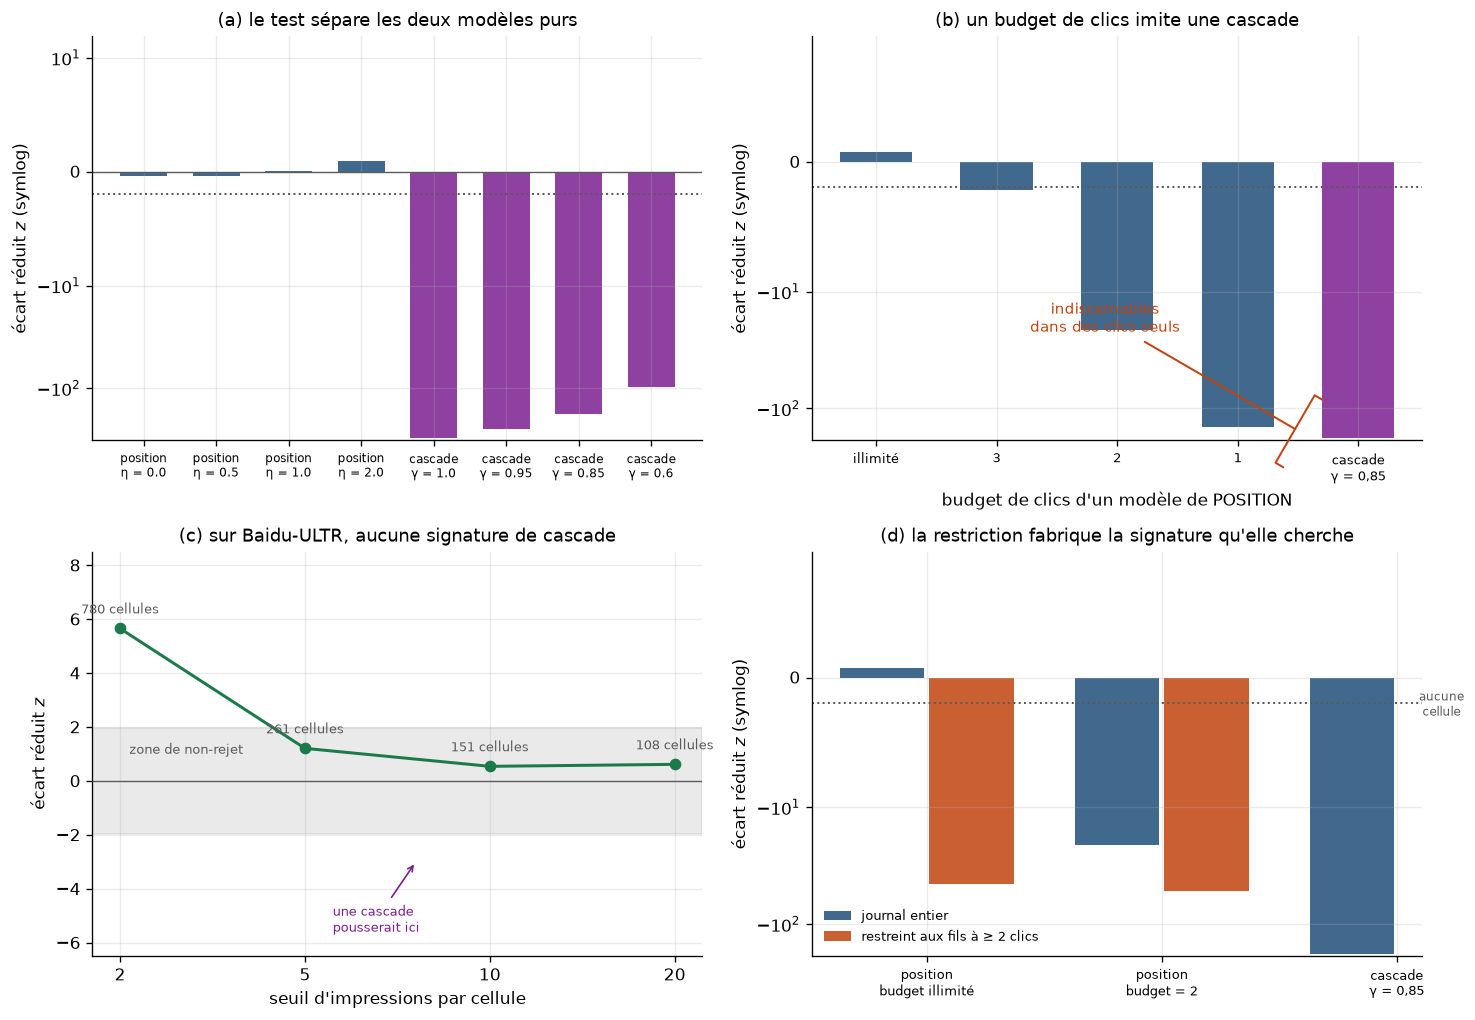

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) contrôles négatif et positif
ax = axes[0, 0]
labels = [f"position\nη = {s}" for s in (0.0, 0.5, 1.0, 2.0)]
labels += [f"cascade\nγ = {c}" for c in (1.0, 0.95, 0.85, 0.6)]
values = [controls[f"position η={s}"].deviation for s in (0.0, 0.5, 1.0, 2.0)]
values += [controls[f"cascade γ={c}"].deviation for c in (1.0, 0.95, 0.85, 0.6)]
colours = [PALETTE["order"]] * 4 + [PALETTE["field"]] * 4
ax.bar(np.arange(len(values)), values, color=colours, alpha=0.85, width=0.65)
ax.axhline(-1.96, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.axhline(0.0, color=PALETTE["neutral"], linewidth=0.8)
ax.set_yscale("symlog", linthresh=10)
ax.set_xticks(np.arange(len(values)))
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("écart réduit $z$ (symlog)")
ax.set_title("(a) le test sépare les deux modèles purs")

# (b) le budget imite la cascade
ax = axes[0, 1]
budgets = [99, 3, 2, 1]
positions = np.arange(len(budgets) + 1)
values = [budget_scan[b][0].deviation for b in budgets] + [reference.deviation]
names = ["illimité", "3", "2", "1", "cascade\nγ = 0,85"]
ax.bar(positions, values, color=[PALETTE["order"]] * 4 + [PALETTE["field"]], alpha=0.85,
       width=0.6)
ax.axhline(-1.96, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.set_yscale("symlog", linthresh=10)
ax.set_xticks(positions)
ax.set_xticklabels(names, fontsize=8)
ax.set_xlabel("budget de clics d'un modèle de POSITION")
ax.set_ylabel("écart réduit $z$ (symlog)")
ax.annotate("indiscernables\ndans des clics seuls", xy=(3.5, -155), xytext=(1.9, -22),
            fontsize=9, color=PALETTE["disorder"], ha="center",
            arrowprops={"arrowstyle": "-[, widthB=2.6, lengthB=0.6",
                        "color": PALETTE["disorder"], "linewidth": 1.2})
ax.set_title("(b) un budget de clics imite une cascade")

# (c) Baidu-ULTR
ax = axes[1, 0]
thresholds = list(baidu_scan)
deviations = [baidu_scan[t].deviation for t in thresholds]
cells = [baidu_scan[t].cells_used for t in thresholds]
ax.plot(np.arange(len(thresholds)), deviations, "o-", color=PALETTE["remedy"], markersize=6,
        label="Baidu-ULTR")
ax.axhspan(-1.96, 1.96, color=PALETTE["neutral"], alpha=0.12)
ax.axhline(0.0, color=PALETTE["neutral"], linewidth=0.8)
ax.text(0.05, 1.0, "zone de non-rejet", fontsize=8, color=PALETTE["neutral"])
ax.annotate("une cascade\npousserait ici", xy=(1.6, -3.0), xytext=(1.15, -5.6), fontsize=8,
            color=PALETTE["field"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["field"], "linewidth": 1.0})
for index, (threshold, count) in enumerate(zip(thresholds, cells, strict=True)):
    ax.annotate(f"{count} cellules", xy=(index, deviations[index]), xytext=(0, 9),
                textcoords="offset points", fontsize=7.5, ha="center",
                color=PALETTE["neutral"])
ax.set_xticks(np.arange(len(thresholds)))
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("seuil d'impressions par cellule")
ax.set_ylabel("écart réduit $z$")
ax.set_ylim(-6.5, 8.5)
ax.set_title("(c) sur Baidu-ULTR, aucune signature de cascade")

# (d) le collider
ax = axes[1, 1]
names = list(collider)
full_values = [collider[name][0] for name in names]
limited_values = [collider[name][1] if collider[name][2] else np.nan for name in names]
positions = np.arange(len(names))
ax.bar(positions - 0.19, full_values, width=0.36, color=PALETTE["order"], alpha=0.85,
       label="journal entier")
ax.bar(positions + 0.19, limited_values, width=0.36, color=PALETTE["disorder"], alpha=0.85,
       label="restreint aux fils à ≥ 2 clics")
for index, name in enumerate(names):
    if not collider[name][2]:
        ax.text(index + 0.19, -1.0, "aucune\ncellule", fontsize=7, ha="center", va="top",
                color=PALETTE["neutral"])
ax.axhline(-1.96, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.set_yscale("symlog", linthresh=10)
ax.set_xticks(positions)
ax.set_xticklabels([name.replace(", ", "\n") for name in names], fontsize=7.5)
ax.set_ylabel("écart réduit $z$ (symlog)")
ax.set_title("(d) la restriction fabrique la signature qu'elle cherche")
ax.legend(loc="lower left", fontsize=8)

save_figure(figure, "fig22_test_de_forme")
plt.show()

## 6. Ce que ce troisième contrôle apporte

**Il existe, et il fonctionne.** Le dépôt dispose désormais de trois contrôles à passer sur un
journal, dans cet ordre :

| Contrôle | Question | Verdict sur MIND | Verdict sur Baidu-ULTR |
|---|---|---|---|
| **échangeabilité** | l'ordre dit-il quelque chose ? | non ($z = +0{,}12$) | oui ($z = -206$) |
| **identifiabilité** | y a-t-il de quoi estimer $\eta$ ? | oui, artificiellement | oui, 55 documents |
| **forme** | l'examen dépend-il de l'amont ? | inapplicable | non détecté ($z = +0{,}5$ à $+0{,}6$) |

**Mais il ne tranche pas ce qu'on voulait trancher.** Un budget de clics imite une cascade, et
rien dans les clics ne les sépare. La question — *quelle exposition attribuer aux rangs
profonds ?* — reste ouverte, et elle demande une mesure de l'examen, non du clic.

**Et il a coûté une erreur, rattrapée.** Restreindre aux sessions à plusieurs clics semblait la
façon évidente de séparer budget et cascade. C'est un collider, et le contrôle sur données
simulées l'a montré avant publication.

## Piste ouverte

Baidu-ULTR publie `displayed_time`, `serp_height` et `slipoff_count_after_click` — des mesures de
l'**examen** et non du clic. Ce dépôt n'a jamais lu ces colonnes. Elles trancheraient précisément
ce que les clics ne peuvent pas : un contenu situé sous un clic a-t-il été affiché assez longtemps
pour être vu ?

C'est la suite directe, elle ne demande aucune donnée nouvelle, et elle est la seule voie connue
pour séparer les deux modèles.